### Navier Stokes Dataset Exploration

In [1]:
import numpy as np
import pywt

# Parameters
wavelet = 'db4'
N = 64  # grid points

# Create a uniform grid on [0, 1)
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]

# Get Daubechies db4 scaling function
phi, psi, x_phi = pywt.Wavelet(wavelet).wavefun(level=2)

# Interpolate scaling function on the uniform grid
phi_interp = np.interp(x, np.linspace(0, 1, len(phi)), phi)

# Approximate derivative using central differences
phi_prime = np.gradient(phi_interp, dx)

# Build approximate differentiation matrix
# Each column corresponds to the derivative of a shifted scaling function
D = np.zeros((N, N))
for j in range(N):
    shifted = np.roll(phi_interp, j)
    shifted_prime = np.roll(phi_prime, j)
    D[:, j] = shifted_prime

# Normalize columns to prevent scaling drift
D /= np.linalg.norm(D, axis=0) + 1e-12

# Print the first few entries
print(D[:5, :5])


[[0.07550543 0.         0.         0.         0.        ]
 [0.07550543 0.07550543 0.         0.         0.        ]
 [0.10524733 0.07550543 0.07550543 0.         0.        ]
 [0.14688599 0.10524733 0.07550543 0.07550543 0.        ]
 [0.16906546 0.14688599 0.10524733 0.07550543 0.07550543]]


In [12]:
import numpy as np
import pywt

def daubechies_diff_matrix(wavelet='db4', N=64):
    w = pywt.Wavelet(wavelet)
    phi, _, _ = w.wavefun(level=5)  # higher level = smoother, finer grid
    x_phi = np.linspace(0, 1, len(phi), endpoint=False)
    dx_phi = x_phi[1] - x_phi[0]

    # Compute derivative of scaling function
    phi_prime = np.gradient(phi, dx_phi)

    # Construct D_{mn} = ∫ phi_m(x) phi_n'(x) dx via numerical integration
    # Assume periodic extension on [0,1) -- PRECOMPUTE THESE 
    D = np.zeros((N, N))
    for n in range(N):
        phi_n_prime = np.roll(phi_prime, n * len(phi)//N)
        for m in range(N):
            phi_m = np.roll(phi, m * len(phi)//N)
            D[m, n] = np.trapz(phi_m * phi_n_prime, x_phi)

    return D


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Use your existing D, x, dx
D = daubechies_diff_matrix(wavelet='db4', N=64)
x = np.linspace(0, 1, 64, endpoint=False)
f = np.sin(2 * np.pi * x)
f_true_deriv = 2 * np.pi * np.cos(2 * np.pi * x)

# Apply differentiation matrix
f_approx_deriv = D @ f

# Compare results
error = np.linalg.norm(f_approx_deriv - f_true_deriv) / np.linalg.norm(f_true_deriv)
print("Relative L2 error:", error)

# Optional: plot
plt.plot(x, f_true_deriv, label="True derivative", lw=2)
plt.plot(x, f_approx_deriv, '--', label="Wavelet derivative")
plt.legend()
plt.show()


NameError: name 'daubechies_diff_matrix' is not defined

In [9]:
D.shape

(64, 64)

Signal shape after squeeze: (129, 129)
CWT coefficient cube shape: (129, 31, 129)


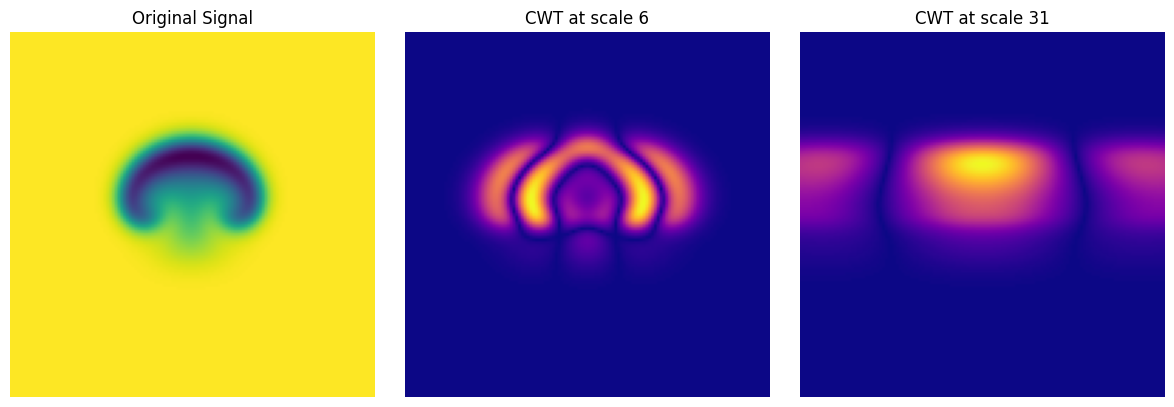

In [6]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

# --- Load field ---
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][43])  # shape: (129,129)

print("Signal shape after squeeze:", signal.shape)

# --- Choose wavelet and scales ---
wavelet = 'mexh'  # Mexican hat (continuous wavelet)
scales = np.arange(1, 32)  # range of scales to analyze

# --- Compute CWT row-wise (since pywt.cwt is 1D) ---
coeffs_rows = []
for row in signal:
    cwtmatr, freqs = pywt.cwt(row, scales, wavelet)
    coeffs_rows.append(np.abs(cwtmatr))

coeffs_rows = np.array(coeffs_rows)  # shape: (nx, n_scales, ny)
print("CWT coefficient cube shape:", coeffs_rows.shape)

# --- Visualize selected scales ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(signal, cmap='viridis')
axs[0].set_title("Original Signal")

axs[1].imshow(coeffs_rows[:, 5, :], cmap='plasma')
axs[1].set_title(f"CWT at scale {scales[5]}")

axs[2].imshow(coeffs_rows[:, -1, :], cmap='plasma')
axs[2].set_title(f"CWT at scale {scales[-1]}")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


CWT cube: (129, 15, 129)


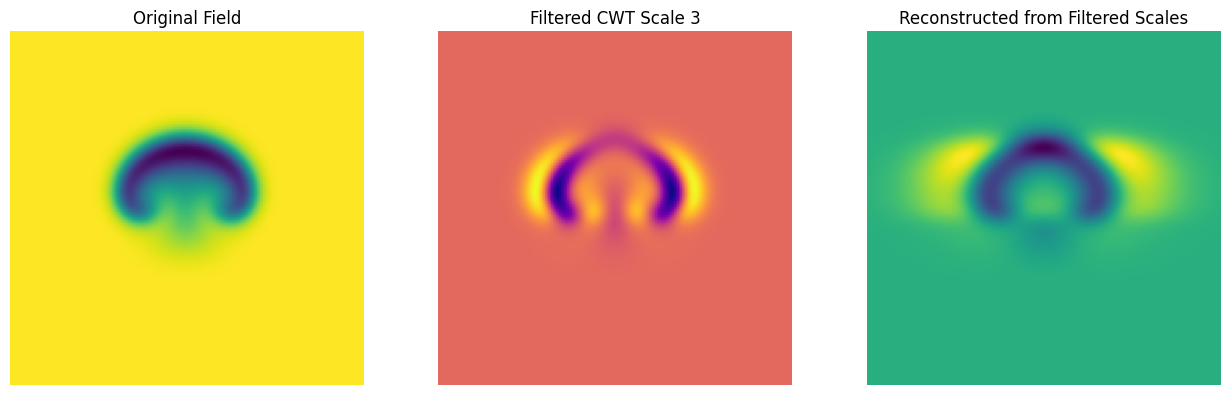

In [9]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# --- Load field ---
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][43])  # shape: (129,129)

wavelet = 'mexh'
scales = np.arange(1, 16)  # scales to explore

# --- Step 1: Compute row-wise CWT to get multiscale representation ---
coeffs_rows = []
for row in signal:
    cwtmatr, freqs = pywt.cwt(row, scales, wavelet)
    coeffs_rows.append(cwtmatr)
coeffs_rows = np.array(coeffs_rows)  # shape: (nx, n_scales, ny)
print("CWT cube:", coeffs_rows.shape)

# --- Step 2: Fourier decomposition per scale ---
def fourier_filter(field, frac_keep=0.3):
    """Keep only low-frequency modes (central region)"""
    F = np.fft.fftshift(np.fft.fft2(field))
    nx, ny = F.shape
    cx, cy = nx//2, ny//2
    kx, ky = int(frac_keep*nx/2), int(frac_keep*ny/2)
    mask = np.zeros_like(F)
    mask[cx-kx:cx+kx, cy-ky:cy+ky] = 1
    F_filtered = F * mask
    return np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))

# --- Step 3: Apply Fourier filtering at each scale ---
filtered_scales = []
for s in range(coeffs_rows.shape[1]):
    scale_field = coeffs_rows[:, s, :]  # 2D field for this scale
    filtered = fourier_filter(scale_field, frac_keep=0.3)
    filtered_scales.append(filtered)
filtered_scales = np.array(filtered_scales)

# --- Step 4: Recombine (sum across scales) ---
reconstructed = np.sum(filtered_scales, axis=0)
reconstructed /= np.max(np.abs(reconstructed))  # normalize

# --- Visualization ---
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(signal, cmap='viridis')
axs[0].set_title("Original Field")

axs[1].imshow(filtered_scales[2], cmap='plasma')
axs[1].set_title(f"Filtered CWT Scale {scales[2]}")

axs[2].imshow(reconstructed, cmap='viridis')
axs[2].set_title("Reconstructed from Filtered Scales")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


CWT coefficient cube: (129, 15, 129)


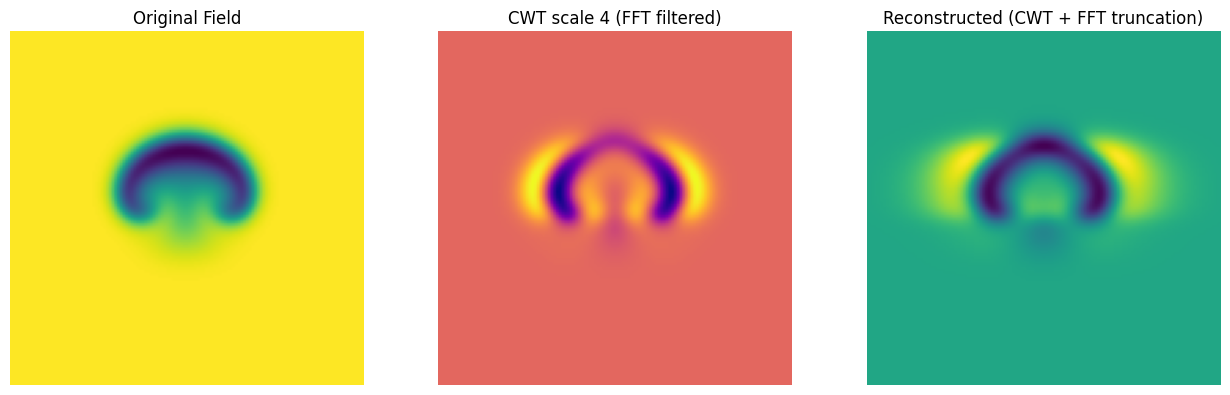

In [15]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# --- Load your field ---
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][43])  # shape: (129,129)

wavelet = 'mexh'
scales = np.arange(1, 16)  # range of wavelet scales

# --- Step 1: CWT row-wise (1D along x for each row in y) ---
coeffs_rows = []
for row in signal:
    cwtmatr, freqs = pywt.cwt(row, scales, wavelet)
    coeffs_rows.append(cwtmatr)
coeffs_rows = np.array(coeffs_rows)  # shape: (nx, n_scales, ny)
print("CWT coefficient cube:", coeffs_rows.shape)

# --- Step 2: Fourier truncation per scale ---
def truncate_fft_modes(field, keep=10):
    """Keep only central (low-frequency) Fourier modes."""
    fft_signal = np.fft.fft2(field)
    fft_shifted = np.fft.fftshift(fft_signal)
    nx, ny = field.shape
    mask = np.zeros_like(fft_shifted, dtype=bool)
    cx, cy = nx // 2, ny // 2
    mask[cx-keep:cx+keep+1, cy-keep:cy+keep+1] = True
    fft_truncated = np.zeros_like(fft_shifted)
    fft_truncated[mask] = fft_shifted[mask]
    return np.fft.ifft2(np.fft.ifftshift(fft_truncated)).real

filtered_scales = []
for s in range(coeffs_rows.shape[1]):
    scale_field = coeffs_rows[:, s, :]
    filtered = truncate_fft_modes(scale_field, keep=21)
    filtered_scales.append(filtered)
filtered_scales = np.array(filtered_scales)

# --- Step 3: Recombine across scales ---
# reconstructed = np.sum(filtered_scales, axis=0)
# reconstructed /= np.max(np.abs(reconstructed))
weights = np.linspace(2.0, 0.2, len(scales))  # heavier weight on fine scales
reconstructed = np.tensordot(weights, filtered_scales, axes=(0,0))


# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(13, 4))

axs[0].imshow(signal, cmap='viridis')
axs[0].set_title("Original Field")
axs[0].axis('off')

axs[1].imshow(filtered_scales[3], cmap='plasma')
axs[1].set_title(f"CWT scale {scales[3]} (FFT filtered)")
axs[1].axis('off')

axs[2].imshow(reconstructed, cmap='viridis')
axs[2].set_title("Reconstructed (CWT + FFT truncation)")
axs[2].axis('off')

plt.tight_layout()
plt.show()


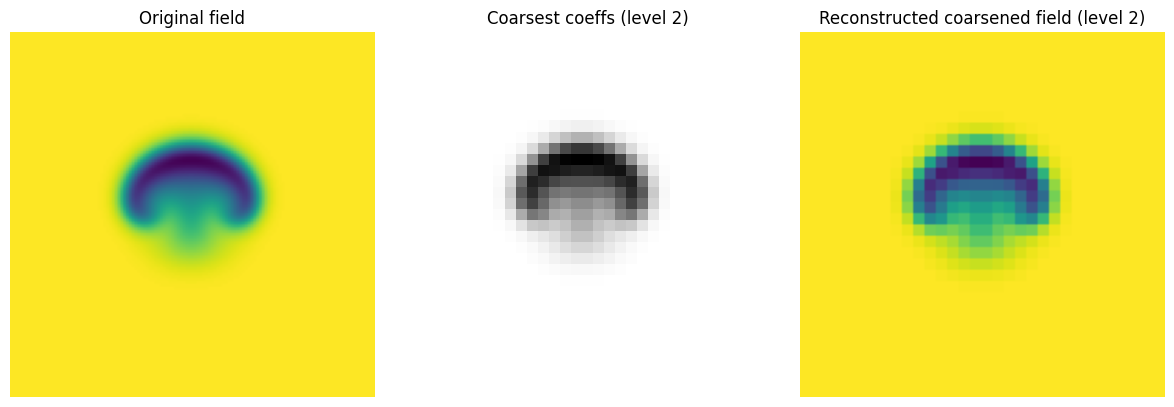

In [1]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

# --- Load signal ---
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][35])  # shape: (129,129)

wavelet = 'haar'
levels = 2  # how many scales to coarsen

# --- Multi-level decomposition ---
coeffs = pywt.wavedec2(signal, wavelet=wavelet, mode='symmetric', level=levels)

# coeffs = [cA_L, (cH_L, cV_L, cD_L), ..., (cH_1, cV_1, cD_1)]
# Keep only the coarsest approximation
cA_L = coeffs[0]
zero_details = [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH, cV, cD) in coeffs[1:]]

# --- Reconstruct coarsened signal ---
coarsened = pywt.waverec2([cA_L, *zero_details], wavelet=wavelet, mode='symmetric')
coarsened = coarsened[:signal.shape[0], :signal.shape[1]]

# --- Visualization ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(signal, cmap='viridis')
axs[0].set_title("Original field")

axs[1].imshow(cA_L, cmap='gray')
axs[1].set_title(f"Coarsest coeffs (level {levels})")

axs[2].imshow(coarsened, cmap='viridis')
axs[2].set_title(f"Reconstructed coarsened field (level {levels})")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


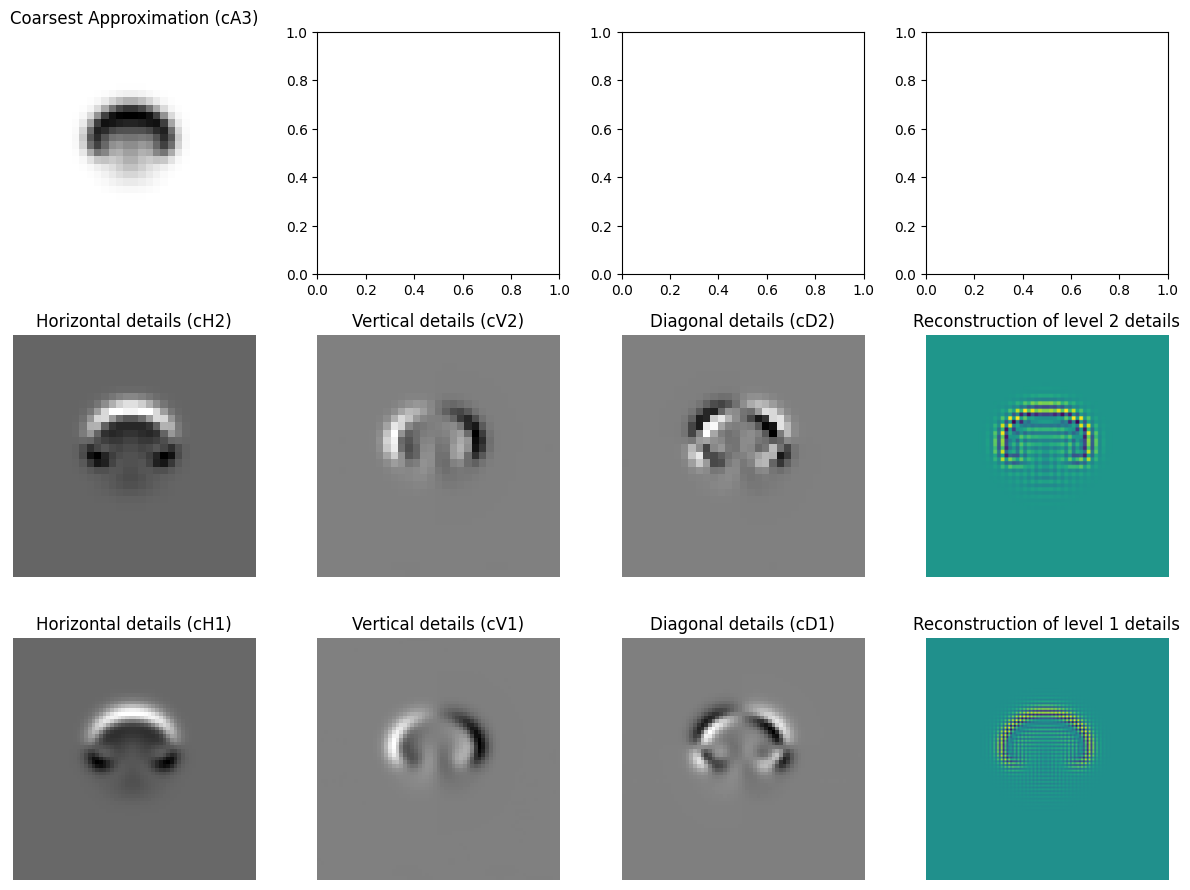

In [2]:
# --- Visualize all levels ---
fig, axs = plt.subplots(levels+1, 4, figsize=(12, 3*(levels+1)))

# Approximation at the coarsest scale
axs[0,0].imshow(coeffs[0], cmap='gray')
axs[0,0].set_title("Coarsest Approximation (cA3)")
axs[0,0].axis('off')

for j, (cH, cV, cD) in enumerate(coeffs[1:], 1):
    axs[j,0].imshow(cH, cmap='gray')
    axs[j,0].set_title(f"Horizontal details (cH{levels-j+1})")
    axs[j,0].axis('off')
    
    axs[j,1].imshow(cV, cmap='gray')
    axs[j,1].set_title(f"Vertical details (cV{levels-j+1})")
    axs[j,1].axis('off')
    
    axs[j,2].imshow(cD, cmap='gray')
    axs[j,2].set_title(f"Diagonal details (cD{levels-j+1})")
    axs[j,2].axis('off')
    
    # Reconstruct using just this level’s detail
    coeffs_zero = [np.zeros_like(coeffs[0])] + [
        (np.zeros_like(ch), np.zeros_like(cv), np.zeros_like(cd)) for (ch, cv, cd) in coeffs[1:]
    ]
    coeffs_zero[j] = (cH, cV, cD)
    detail_level = pywt.waverec2(coeffs_zero, wavelet)
    axs[j,3].imshow(detail_level, cmap='viridis')
    axs[j,3].set_title(f"Reconstruction of level {levels-j+1} details")
    axs[j,3].axis('off')

plt.tight_layout()
plt.show()


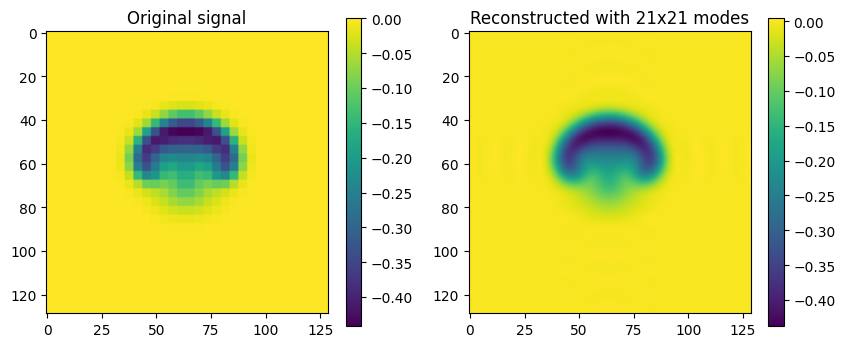

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Assume detail_level or coarsened is your 2D signal
signal = coarsened  # or detail_level

# --- Forward FFT ---
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

# --- Keep only a small number of modes ---
nx, ny = signal.shape
keep = 10  # number of low-frequency modes to retain in each direction

# Zero-out everything except a small central block
mask = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask[cx-keep:cx+keep+1, cy-keep:cy+keep+1] = True

fft_truncated = np.zeros_like(fft_shifted)
fft_truncated[mask] = fft_shifted[mask]

# --- Inverse FFT for reconstruction ---
recon = np.fft.ifft2(np.fft.ifftshift(fft_truncated)).real

# --- Plot ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Reconstructed with {keep*2+1}x{keep*2+1} modes")
plt.imshow(recon, cmap='viridis')
plt.colorbar()
plt.show()


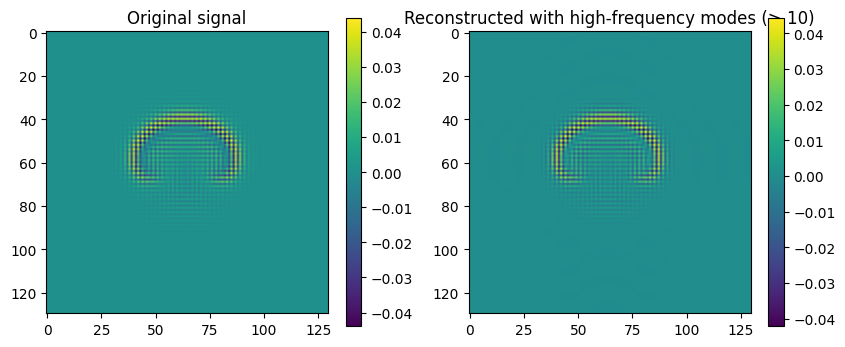

In [4]:
import numpy as np
import matplotlib.pyplot as plt

signal = detail_level  # your 2D array

# --- Forward FFT ---
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

# --- Remove low-frequency modes (keep only high-frequency) ---
nx, ny = signal.shape
remove = 10  # number of low-frequency modes to remove around the center

mask = np.ones_like(fft_shifted, dtype=bool)  # start with all True
cx, cy = nx // 2, ny // 2
mask[cx-remove:cx+remove+1, cy-remove:cy+remove+1] = False  # zero out the central region

fft_truncated = np.zeros_like(fft_shifted)
fft_truncated[mask] = fft_shifted[mask]  # keep only high-freq components
recon_high = np.fft.ifft2(np.fft.ifftshift(fft_truncated)).real

# --- Plot ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Reconstructed with high-frequency modes (> {remove})")
plt.imshow(recon_high, cmap='viridis')
plt.colorbar()
plt.show()


ADAPTIVE WAVELET TRUNCATION DEMONSTRATION
Signal shape: (129, 129)
Signal range: [-0.416, 0.000]
Signal L2 norm: 10.348

Performing multi-level wavelet decomposition...

Energy Distribution:
  approx              :       107.49 (99.19%)
  scale_1_H           :         0.25 ( 0.23%)
  scale_1_V           :         0.19 ( 0.18%)
  scale_1_D           :         0.00 ( 0.00%)
  scale_1_total       :         0.44 ( 0.41%)
  TOTAL               :       108.37

Perfect reconstruction error: 0.000011%

--------------------------------------------------------------------------------
STRATEGY 1: Global Adaptive Thresholding (95% energy)
--------------------------------------------------------------------------------
Kept 328 / 17956 coefficients
Compression ratio: 0.0183
Energy retained: 0.9506
Reconstruction error: 22.585%

--------------------------------------------------------------------------------
STRATEGY 2: Per-Scale Adaptive Thresholding (95% per scale)
--------------------------------

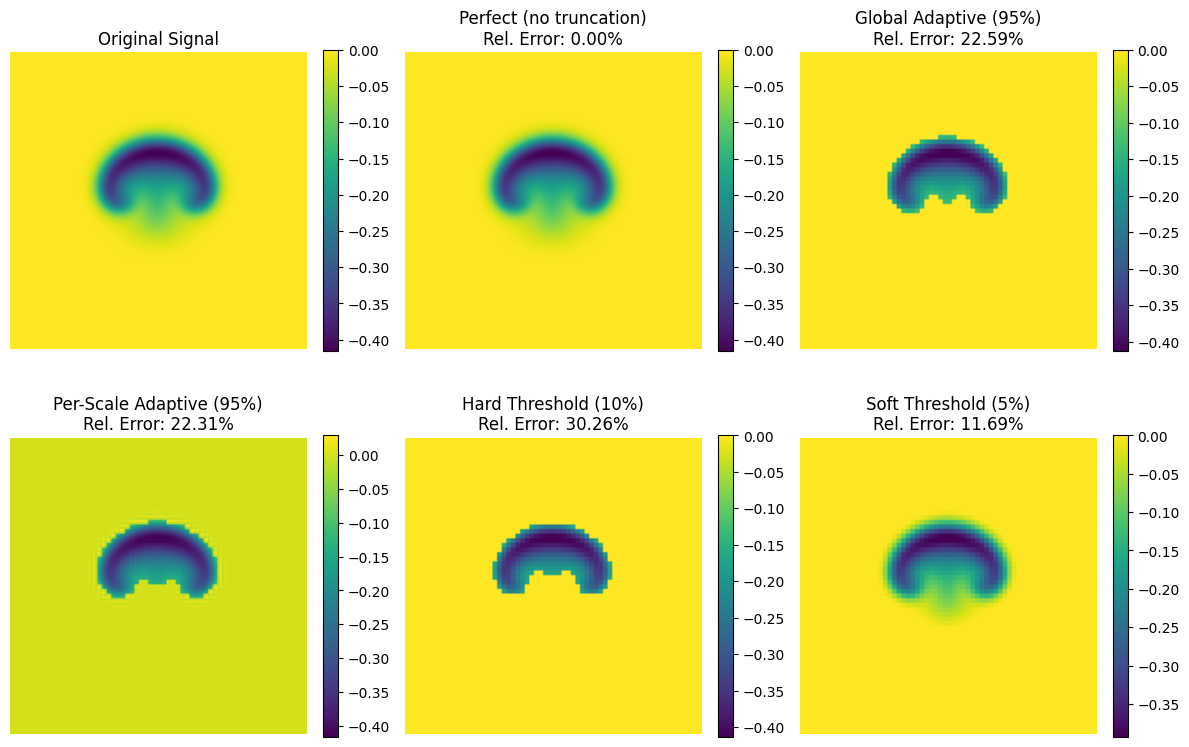

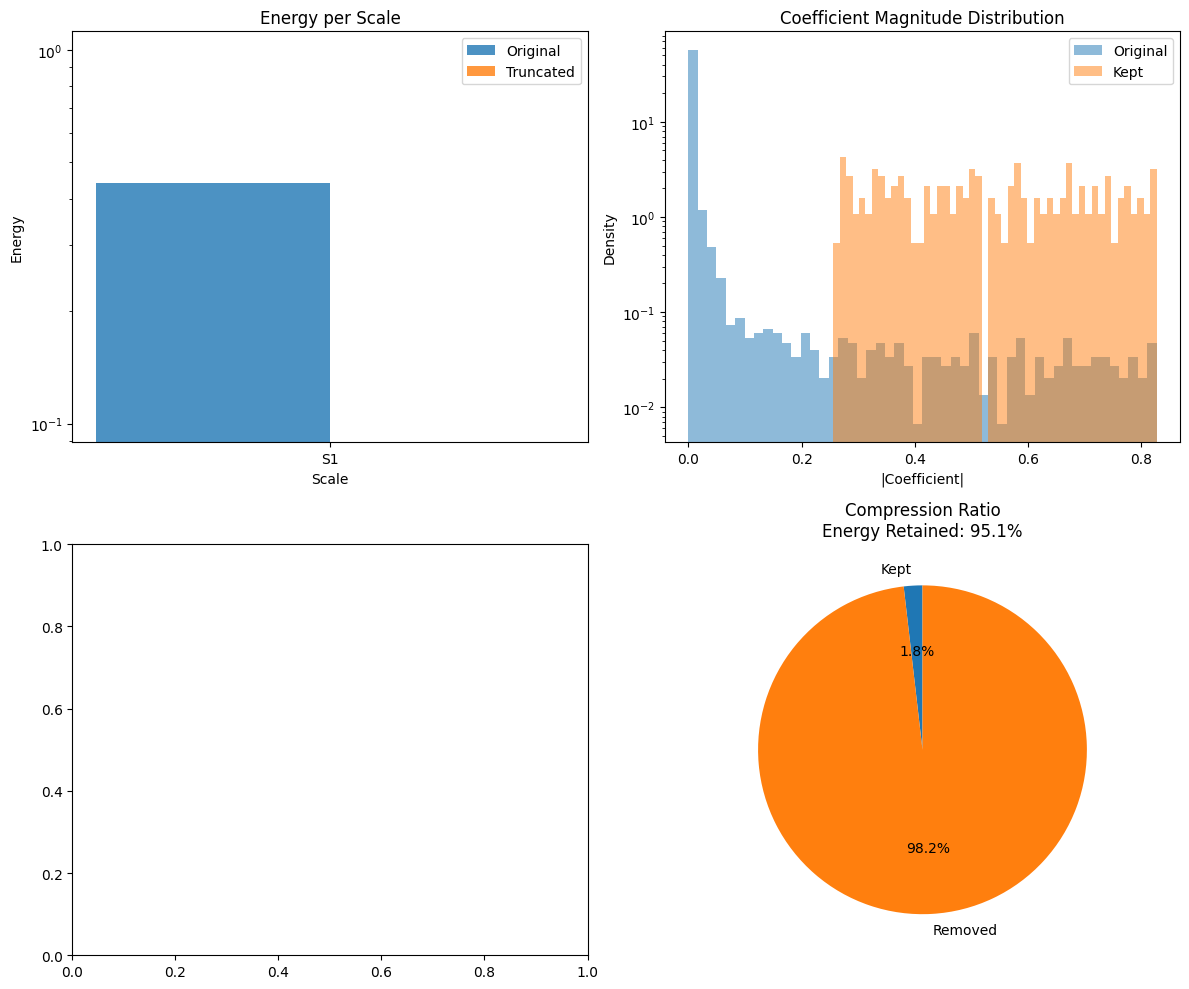


Done!


In [109]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

# ============================================================================ #
#                        ADAPTIVE WAVELET TRUNCATION                           #
# ============================================================================ #

class AdaptiveWaveletTruncation:
    """
    Adaptive thresholding for multi-level 2D wavelet decomposition.
    Implements energy-based and scale-adaptive truncation strategies.
    """
    
    @staticmethod
    def multilevel_dwt2(signal: np.ndarray, wavelet: str = 'db4', 
                        level: int = 3, mode: str = 'symmetric') -> List:
        """
        Perform multi-level 2D discrete wavelet transform.
        
        Returns:
            coeffs: [cA_n, (cH_n, cV_n, cD_n), ..., (cH_1, cV_1, cD_1)]
                   where n = level
        """
        return pywt.wavedec2(signal, wavelet, mode=mode, level=level)
    
    @staticmethod
    def energy_per_scale(coeffs: List) -> Dict[str, float]:
        """
        Compute energy (L2 norm squared) at each scale.
        
        Args:
            coeffs: Output from wavedec2
            
        Returns:
            Dictionary with energy at each scale and coefficient type
        """
        energies = {}
        
        # Approximation coefficients (coarsest scale)
        cA = coeffs[0]
        energies['approx'] = np.sum(np.abs(cA)**2)
        
        # Detail coefficients at each scale
        for j, (cH, cV, cD) in enumerate(coeffs[1:]):
            scale = len(coeffs) - 1 - j  # j=0 is finest scale
            energies[f'scale_{scale}_H'] = np.sum(np.abs(cH)**2)
            energies[f'scale_{scale}_V'] = np.sum(np.abs(cV)**2)
            energies[f'scale_{scale}_D'] = np.sum(np.abs(cD)**2)
            energies[f'scale_{scale}_total'] = (
                energies[f'scale_{scale}_H'] + 
                energies[f'scale_{scale}_V'] + 
                energies[f'scale_{scale}_D']
            )
        
        total_energy = sum(energies.values())
        energies['total'] = total_energy
        
        return energies
    
    @staticmethod
    def adaptive_threshold_global(coeffs: List, energy_ratio: float = 0.95) -> Tuple[List, Dict]:
        """
        Global energy-based thresholding: keep coefficients that capture 
        energy_ratio of total energy across ALL scales.
        
        This is the most aggressive compression strategy.
        """
        # Flatten all coefficients with their indices
        all_coeffs = []
        
        # Approximation
        cA = coeffs[0]
        for idx in np.ndindex(cA.shape):
            all_coeffs.append((np.abs(cA[idx])**2, ('approx', idx)))
        
        # Details
        for j, (cH, cV, cD) in enumerate(coeffs[1:]):
            scale = len(coeffs) - 1 - j
            for idx in np.ndindex(cH.shape):
                all_coeffs.append((np.abs(cH[idx])**2, (f'scale_{scale}', 'H', idx)))
                all_coeffs.append((np.abs(cV[idx])**2, (f'scale_{scale}', 'V', idx)))
                all_coeffs.append((np.abs(cD[idx])**2, (f'scale_{scale}', 'D', idx)))
        
        # Sort by energy
        all_coeffs.sort(key=lambda x: x[0], reverse=True)
        
        # Find threshold
        total_energy = sum(c[0] for c in all_coeffs)
        cumsum = 0
        threshold_idx = 0
        
        for i, (energy, _) in enumerate(all_coeffs):
            cumsum += energy
            if cumsum >= energy_ratio * total_energy:
                threshold_idx = i
                break
        
        # Create mask
        kept_indices = set(c[1] for c in all_coeffs[:threshold_idx+1])
        
        # Apply threshold
        coeffs_trunc = [np.zeros_like(coeffs[0])]
        
        # Threshold approximation
        for idx in np.ndindex(coeffs[0].shape):
            if ('approx', idx) in kept_indices:
                coeffs_trunc[0][idx] = coeffs[0][idx]
        
        # Threshold details
        for j, (cH, cV, cD) in enumerate(coeffs[1:]):
            scale = len(coeffs) - 1 - j
            cH_t = np.zeros_like(cH)
            cV_t = np.zeros_like(cV)
            cD_t = np.zeros_like(cD)
            
            for idx in np.ndindex(cH.shape):
                if (f'scale_{scale}', 'H', idx) in kept_indices:
                    cH_t[idx] = cH[idx]
                if (f'scale_{scale}', 'V', idx) in kept_indices:
                    cV_t[idx] = cV[idx]
                if (f'scale_{scale}', 'D', idx) in kept_indices:
                    cD_t[idx] = cD[idx]
            
            coeffs_trunc.append((cH_t, cV_t, cD_t))
        
        stats = {
            'total_coeffs': len(all_coeffs),
            'kept_coeffs': threshold_idx + 1,
            'compression_ratio': (threshold_idx + 1) / len(all_coeffs),
            'energy_retained': cumsum / total_energy
        }
        
        return coeffs_trunc, stats
    
    @staticmethod
    def adaptive_threshold_per_scale(coeffs: List, energy_ratio: float = 0.95) -> Tuple[List, Dict]:
        """
        Per-scale energy thresholding: keep energy_ratio of energy at EACH scale.
        
        This preserves multi-resolution structure better but compresses less.
        """
        coeffs_trunc = []
        stats = {'scales': {}}
        
        # Approximation - always keep most of it
        cA = coeffs[0]
        flat_cA = np.abs(cA.flatten())**2
        sorted_indices = np.argsort(flat_cA)[::-1]
        
        cumsum = np.cumsum(flat_cA[sorted_indices])
        total = cumsum[-1]
        keep_idx = np.searchsorted(cumsum, energy_ratio * total)
        
        threshold = flat_cA[sorted_indices[keep_idx]]
        cA_trunc = np.where(np.abs(cA)**2 >= threshold, cA, 0)
        coeffs_trunc.append(cA_trunc)
        
        stats['scales']['approx'] = {
            'kept': keep_idx + 1,
            'total': len(flat_cA),
            'ratio': (keep_idx + 1) / len(flat_cA)
        }
        
        # Details at each scale
        for j, (cH, cV, cD) in enumerate(coeffs[1:]):
            scale = len(coeffs) - 1 - j
            
            # Process each orientation separately
            def threshold_detail(c, name):
                flat = np.abs(c.flatten())**2
                sorted_idx = np.argsort(flat)[::-1]
                cumsum = np.cumsum(flat[sorted_idx])
                total = cumsum[-1] if cumsum[-1] > 0 else 1
                keep = np.searchsorted(cumsum, energy_ratio * total)
                thresh = flat[sorted_idx[min(keep, len(sorted_idx)-1)]]
                
                stats['scales'][f'scale_{scale}_{name}'] = {
                    'kept': keep + 1,
                    'total': len(flat),
                    'ratio': (keep + 1) / len(flat)
                }
                
                return np.where(np.abs(c)**2 >= thresh, c, 0)
            
            cH_t = threshold_detail(cH, 'H')
            cV_t = threshold_detail(cV, 'V')
            cD_t = threshold_detail(cD, 'D')
            
            coeffs_trunc.append((cH_t, cV_t, cD_t))
        
        return coeffs_trunc, stats
    
    @staticmethod
    def hard_threshold(coeffs: List, threshold: float) -> List:
        """
        Hard thresholding: set all coefficients with |c| < threshold to zero.
        """
        coeffs_trunc = [np.where(np.abs(coeffs[0]) >= threshold, coeffs[0], 0)]
        
        for (cH, cV, cD) in coeffs[1:]:
            cH_t = np.where(np.abs(cH) >= threshold, cH, 0)
            cV_t = np.where(np.abs(cV) >= threshold, cV, 0)
            cD_t = np.where(np.abs(cD) >= threshold, cD, 0)
            coeffs_trunc.append((cH_t, cV_t, cD_t))
        
        return coeffs_trunc
    
    @staticmethod
    def soft_threshold(coeffs: List, threshold: float) -> List:
        """
        Soft thresholding: shrink coefficients towards zero.
        """
        def soft_thresh(c, t):
            return np.sign(c) * np.maximum(np.abs(c) - t, 0)
        
        coeffs_trunc = [soft_thresh(coeffs[0], threshold)]
        
        for (cH, cV, cD) in coeffs[1:]:
            coeffs_trunc.append((
                soft_thresh(cH, threshold),
                soft_thresh(cV, threshold),
                soft_thresh(cD, threshold)
            ))
        
        return coeffs_trunc


# ============================================================================ #
#                              VISUALIZATION                                   #
# ============================================================================ #


def compare_reconstructions(signal: np.ndarray, reconstructions: Dict[str, np.ndarray]):
    """Compare original signal with various reconstructions."""
    n = len(reconstructions) + 1
    fig, axes = plt.subplots(2, (n+1)//2, figsize=(4*((n+1)//2), 8))
    axes = axes.flatten()
    
    # Original
    im0 = axes[0].imshow(signal, cmap='viridis')
    axes[0].set_title("Original Signal")
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Reconstructions
    for idx, (name, recon) in enumerate(reconstructions.items(), 1):
        # Compute error
        error = np.abs(signal - recon)
        rel_error = np.linalg.norm(error) / np.linalg.norm(signal) * 100
        
        im = axes[idx].imshow(recon, cmap='viridis')
        axes[idx].set_title(f"{name}\nRel. Error: {rel_error:.2f}%")
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046)
    
    # Hide unused axes
    for idx in range(len(reconstructions) + 1, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

def plot_coefficient_statistics(coeffs_original: List, coeffs_truncated: List, stats: Dict):
    """Plot statistics about coefficient truncation."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Energy distribution
    energies_orig = AdaptiveWaveletTruncation.energy_per_scale(coeffs_original)
    energies_trunc = AdaptiveWaveletTruncation.energy_per_scale(coeffs_truncated)
    
    scales = [k for k in energies_orig.keys() if k.startswith('scale') and k.endswith('total')]
    orig_vals = [energies_orig[k] for k in scales]
    trunc_vals = [energies_trunc[k] for k in scales]
    
    x = np.arange(len(scales))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, orig_vals, width, label='Original', alpha=0.8)
    axes[0, 0].bar(x + width/2, trunc_vals, width, label='Truncated', alpha=0.8)
    axes[0, 0].set_xlabel('Scale')
    axes[0, 0].set_ylabel('Energy')
    axes[0, 0].set_title('Energy per Scale')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels([k.replace('scale_', 'S').replace('_total', '') for k in scales])
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')
    
    # Coefficient histogram
    all_orig = np.concatenate([coeffs_original[0].flatten()] + 
                               [c.flatten() for detail in coeffs_original[1:] for c in detail])
    all_trunc = np.concatenate([coeffs_truncated[0].flatten()] + 
                                [c.flatten() for detail in coeffs_truncated[1:] for c in detail])
    
    axes[0, 1].hist(np.abs(all_orig), bins=50, alpha=0.5, label='Original', density=True)
    axes[0, 1].hist(np.abs(all_trunc[all_trunc != 0]), bins=50, alpha=0.5, label='Kept', density=True)
    axes[0, 1].set_xlabel('|Coefficient|')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].set_title('Coefficient Magnitude Distribution')
    axes[0, 1].set_yscale('log')
    axes[0, 1].legend()
    
    # Sparsity per scale
    if 'scales' in stats:
        scale_names = [k for k in stats['scales'].keys()]
        sparsity = [1 - stats['scales'][k]['ratio'] for k in scale_names]
        
        axes[1, 0].barh(scale_names, sparsity)
        axes[1, 0].set_xlabel('Sparsity (fraction zeros)')
        axes[1, 0].set_title('Sparsity per Scale')
        axes[1, 0].set_xlim([0, 1])
    
    # Compression stats
    if 'compression_ratio' in stats:
        labels = ['Kept', 'Removed']
        sizes = [stats['compression_ratio'], 1 - stats['compression_ratio']]
        axes[1, 1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title(f"Compression Ratio\nEnergy Retained: {stats.get('energy_retained', 0)*100:.1f}%")
    
    plt.tight_layout()
    return fig


# ============================================================================ #
#                                  MAIN DEMO                                   #
# ============================================================================ #

# Load data
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][43])

print("="*80)
print("ADAPTIVE WAVELET TRUNCATION DEMONSTRATION")
print("="*80)
print(f"Signal shape: {signal.shape}")
print(f"Signal range: [{signal.min():.3f}, {signal.max():.3f}]")
print(f"Signal L2 norm: {np.linalg.norm(signal):.3f}")
print()

# Parameters
wavelet = 'bior1.3'
level = 1  # 3-level decomposition
mode = 'symmetric'

# Multi-level decomposition
print("Performing multi-level wavelet decomposition...")
coeffs_original = AdaptiveWaveletTruncation.multilevel_dwt2(signal, wavelet, level, mode)

# Compute energy distribution
energies = AdaptiveWaveletTruncation.energy_per_scale(coeffs_original)
print("\nEnergy Distribution:")
for key, val in energies.items():
    if key != 'total':
        print(f"  {key:20s}: {val:12.2f} ({val/energies['total']*100:5.2f}%)")
print(f"  {'TOTAL':20s}: {energies['total']:12.2f}")
print()

# Reconstruct different truncation strategies
reconstructions = {}

# 1. No truncation (perfect reconstruction)
recon_perfect = pywt.waverec2(coeffs_original, wavelet, mode=mode)
recon_perfect = recon_perfect[:signal.shape[0], :signal.shape[1]]
reconstructions['Perfect (no truncation)'] = recon_perfect
print(f"Perfect reconstruction error: {np.linalg.norm(signal - recon_perfect) / np.linalg.norm(signal) * 100:.6f}%")

# 2. Global adaptive (most aggressive)
print("\n" + "-"*80)
print("STRATEGY 1: Global Adaptive Thresholding (95% energy)")
print("-"*80)
coeffs_global, stats_global = AdaptiveWaveletTruncation.adaptive_threshold_global(
    coeffs_original, energy_ratio=0.95
)
recon_global = pywt.waverec2(coeffs_global, wavelet, mode=mode)
recon_global = recon_global[:signal.shape[0], :signal.shape[1]]
reconstructions['Global Adaptive (95%)'] = recon_global
print(f"Kept {stats_global['kept_coeffs']} / {stats_global['total_coeffs']} coefficients")
print(f"Compression ratio: {stats_global['compression_ratio']:.4f}")
print(f"Energy retained: {stats_global['energy_retained']:.4f}")
print(f"Reconstruction error: {np.linalg.norm(signal - recon_global) / np.linalg.norm(signal) * 100:.3f}%")

# 3. Per-scale adaptive
print("\n" + "-"*80)
print("STRATEGY 2: Per-Scale Adaptive Thresholding (95% per scale)")
print("-"*80)
coeffs_perscale, stats_perscale = AdaptiveWaveletTruncation.adaptive_threshold_per_scale(
    coeffs_original, energy_ratio=0.95
)
recon_perscale = pywt.waverec2(coeffs_perscale, wavelet, mode=mode)
recon_perscale = recon_perscale[:signal.shape[0], :signal.shape[1]]
reconstructions['Per-Scale Adaptive (95%)'] = recon_perscale
print("Sparsity per scale:")
for key, val in stats_perscale['scales'].items():
    print(f"  {key:20s}: kept {val['kept']:5d} / {val['total']:5d} ({val['ratio']:.4f})")
print(f"Reconstruction error: {np.linalg.norm(signal - recon_perscale) / np.linalg.norm(signal) * 100:.3f}%")

# 4. Hard threshold
print("\n" + "-"*80)
print("STRATEGY 3: Hard Thresholding (threshold = 0.1 * max)")
print("-"*80)
max_coef = max(np.abs(coeffs_original[0]).max(),
               max(np.abs(c).max() for detail in coeffs_original[1:] for c in detail))
threshold = 0.4 * max_coef
coeffs_hard = AdaptiveWaveletTruncation.hard_threshold(coeffs_original, threshold)
recon_hard = pywt.waverec2(coeffs_hard, wavelet, mode=mode)
recon_hard = recon_hard[:signal.shape[0], :signal.shape[1]]
reconstructions['Hard Threshold (10%)'] = recon_hard
n_zeros_hard = sum(np.sum(c == 0) for c in [coeffs_hard[0]] + [d for detail in coeffs_hard[1:] for d in detail])
n_total = sum(c.size for c in [coeffs_original[0]] + [d for detail in coeffs_original[1:] for d in detail])
print(f"Threshold value: {threshold:.6f}")
print(f"Zeros: {n_zeros_hard} / {n_total} ({n_zeros_hard/n_total:.4f})")
print(f"Reconstruction error: {np.linalg.norm(signal - recon_hard) / np.linalg.norm(signal) * 100:.3f}%")

# 5. Soft threshold
print("\n" + "-"*80)
print("STRATEGY 4: Soft Thresholding (threshold = 0.05 * max)")
print("-"*80)
threshold_soft = 0.05 * max_coef
coeffs_soft = AdaptiveWaveletTruncation.soft_threshold(coeffs_original, threshold_soft)
recon_soft = pywt.waverec2(coeffs_soft, wavelet, mode=mode)
recon_soft = recon_soft[:signal.shape[0], :signal.shape[1]]
reconstructions['Soft Threshold (5%)'] = recon_soft
n_zeros_soft = sum(np.sum(c == 0) for c in [coeffs_soft[0]] + [d for detail in coeffs_soft[1:] for d in detail])
print(f"Threshold value: {threshold_soft:.6f}")
print(f"Zeros: {n_zeros_soft} / {n_total} ({n_zeros_soft/n_total:.4f})")
print(f"Reconstruction error: {np.linalg.norm(signal - recon_soft) / np.linalg.norm(signal) * 100:.3f}%")

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

# Visualizations
fig3 = compare_reconstructions(signal, reconstructions)
fig4 = plot_coefficient_statistics(coeffs_original, coeffs_global, stats_global)

plt.show()

print("\nDone!")

In [127]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# ============================================================================ #
#                         SIMPLE 1D WAVELET DEMO                               #
# ============================================================================ #

# Create test signal
x = np.linspace(0, 2*np.pi, 256)
signal = np.sin(x) + 0.3*np.sin(5*x)

# Multi-level decomposition
wavelet = 'mexh'
level = 1
coeffs = pywt.wavedec(signal, wavelet, level=level)

print(f"Original signal length: {len(signal)}")
print(f"Decomposition levels: {level}")
print(f"Approximation shape: {coeffs[0].shape}")
for i, c in enumerate(coeffs[1:], 1):
    print(f"Detail {i} shape: {c.shape}")

# ============================================================================ #
#                         TRUNCATION STRATEGIES                                #
# ============================================================================ #

def truncate_energy(arr, energy_ratio=0.95):
    """Keep coefficients capturing energy_ratio of energy."""
    idx = np.argsort(np.abs(arr))[::-1]
    energies = arr[idx]**2
    cumsum = np.cumsum(energies)
    cutoff = np.searchsorted(cumsum, energy_ratio * cumsum[-1]) + 1
    mask = np.zeros_like(arr)
    mask[idx[:cutoff]] = 1
    return arr * mask

def truncate_hard(arr, threshold):
    """Hard threshold: zero out coefficients below threshold."""
    return np.where(np.abs(arr) > threshold, arr, 0)

def truncate_top_k(arr, k):
    """Keep only top k largest coefficients."""
    idx = np.argsort(np.abs(arr))[::-1]
    mask = np.zeros_like(arr)
    mask[idx[:k]] = 1
    return arr * mask

# ============================================================================ #
#                         APPLY DIFFERENT METHODS                              #
# ============================================================================ #

reconstructions = {}

# Method 1: Energy-based (95%)
coeffs_energy = [truncate_energy(c, 0.95) for c in coeffs]
reconstructions['Energy 95%'] = pywt.waverec(coeffs_energy, wavelet)[:len(signal)]

# Method 2: Energy-based (80%)
coeffs_energy80 = [truncate_energy(c, 0.80) for c in coeffs]
reconstructions['Energy 80%'] = pywt.waverec(coeffs_energy80, wavelet)[:len(signal)]

# Method 3: Hard threshold
threshold = 0.4 * np.max([np.abs(c).max() for c in coeffs])
coeffs_hard = [truncate_hard(c, threshold) for c in coeffs]
reconstructions['Hard thresh'] = pywt.waverec(coeffs_hard, wavelet)[:len(signal)]

# Method 4: Top-K per level
coeffs_topk = [truncate_top_k(c, len(c)//2) for c in coeffs]  # Keep 50%
reconstructions['Top-K 50%'] = pywt.waverec(coeffs_topk, wavelet)[:len(signal)]

# ============================================================================ #
#                              VISUALIZATION                                   #
# ============================================================================ #

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Plot 1: Original signal
axes[0, 0].plot(x, signal, 'b-', linewidth=1)
axes[0, 0].set_title('Original Signal', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Wavelet coefficients (original)
axes[0, 1].bar(range(len(coeffs[0])), coeffs[0], alpha=0.7, label='Approx')
axes[0, 1].set_title('Approximation Coefficients', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Plots 3-6: Reconstructions
for idx, (name, recon) in enumerate(reconstructions.items()):
    row = 1 + idx // 2
    col = idx % 2
    
    error = np.linalg.norm(signal - recon) / np.linalg.norm(signal) * 100
    
    axes[row, col].plot(x, signal, 'b-', alpha=0.3, label='Original', linewidth=1)
    axes[row, col].plot(x, recon, 'r--', label='Reconstructed', linewidth=1.5)
    axes[row, col].set_title(f'{name}\nError: {error:.2f}%', fontsize=11, fontweight='bold')
    axes[row, col].grid(alpha=0.3)
    axes[row, col].legend()

plt.tight_layout()

# ============================================================================ #
#                         SPARSITY COMPARISON                                  #
# ============================================================================ #

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))

methods = [
    ('Energy 95%', coeffs_energy),
    ('Energy 80%', coeffs_energy80),
    ('Hard thresh', coeffs_hard),
    ('Top-K 50%', coeffs_topk)
]

for idx, (name, coeffs_trunc) in enumerate(methods):
    ax = axes2[idx // 2, idx % 2]
    
    # Flatten all coefficients
    original_flat = np.concatenate([c for c in coeffs])
    truncated_flat = np.concatenate([c for c in coeffs_trunc])
    
    # Count zeros
    n_zeros = np.sum(truncated_flat == 0)
    sparsity = n_zeros / len(truncated_flat) * 100
    
    # Plot histogram
    ax.hist(np.abs(original_flat), bins=50, alpha=0.5, label='Original', density=True)
    ax.hist(np.abs(truncated_flat[truncated_flat != 0]), bins=50, alpha=0.5, 
            label='Kept', density=True)
    ax.set_xlabel('|Coefficient|')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nSparsity: {sparsity:.1f}%', fontweight='bold')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

# ============================================================================ #
#                             PRINT STATISTICS                                 #
# ============================================================================ #

print("\n" + "="*60)
print("TRUNCATION STATISTICS")
print("="*60)

for name, recon in reconstructions.items():
    error = np.linalg.norm(signal - recon) / np.linalg.norm(signal) * 100
    print(f"{name:20s}: Error = {error:6.3f}%")

plt.show()

ValueError: A ContinuousWavelet object was provided, but only discrete Wavelet objects are supported by this function.  A list of all supported discrete wavelets can be obtained by running:
print(pywt.wavelist(kind='discrete'))

In [124]:
coeffs_topk[1]

array([ 0.        , -0.        , -0.07537116,  0.06077953, -0.06984708,
       -0.09277862,  0.05476122, -0.        , -0.06185353, -0.        ,
        0.        ,  0.        , -0.        ,  0.05544216,  0.08142338,
        0.06572483,  0.05713617, -0.        ,  0.        ,  0.        ,
        0.03186403, -0.10614808,  0.        , -0.        , -0.        ,
       -0.06869952, -0.07355668,  0.05282342,  0.11223463,  0.        ,
       -0.        ,  0.06096258,  0.04951411, -0.11641419,  0.        ,
        0.06296636,  0.05239198, -0.        , -0.05717809, -0.07141833,
        0.        , -0.07244095,  0.        ,  0.03423981, -0.        ,
       -0.        ,  0.        , -0.        , -0.        ,  0.04074669,
       -0.        ,  0.05307647,  0.04182555, -0.07299293,  0.04076464,
        0.        , -0.03496948,  0.04101534,  0.        ,  0.06253248,
       -0.        ,  0.        ,  0.        ,  0.        ,  0.03860636,
        0.08091559, -0.07248152, -0.05657384, -0.03977428,  0.  

In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, vmap

def Pn(n, x):
    """Compute Legendre polynomial of degree n recursively."""
    if n == 0: return jnp.ones_like(x)
    if n == 1: return x
    return ((2*n-1)*x*Pn(n-1, x) - (n-1)*Pn(n-2, x)) / n

def legendre_wavelet(n, j, k, x):
    """Legendre wavelet basis ψ_{j,k}(x)."""
    ξ = 2**j * x - k
    mask = (ξ >= 0) & (ξ <= 1)
    return 2**(j/2) * Pn(n, 2*ξ - 1) * mask

def u(x, coeffs, n, j_values, k_values):
    """Wavelet expansion."""
    return sum(c * legendre_wavelet(n, j, k, x)
               for c, j, k in zip(coeffs, j_values, k_values))


In [131]:
n = 1                      # Legendre degree (P1)
j_values = jnp.array([0, 0, 1, 1])  # two scales
k_values = jnp.array([0, 1, 0, 1])  # shifts per scale
coeffs = jnp.array([0.5, -0.2, 0.1, -0.1])  # initial guess


du_dx = grad(u, argnums=0)(x, coeffs, n, j_values, k_values)
d2u_dx2 = grad(lambda x: grad(u, argnums=0)(x, coeffs, n, j_values, k_values))(x)


TypeError: Gradient only defined for scalar-output functions. Output had shape: (256,).

In [14]:
import jax
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

In [18]:
data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/test_easy_hard/uhat.npy', allow_pickle=True)

In [15]:
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_easy.npy')

In [7]:
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u4_yaws_hard.npy')

In [17]:
import hashlib
import numpy as np

def array_hash(a):
    a = np.asarray(a)
    h = hashlib.sha256()
    h.update(a.tobytes())
    return h.hexdigest()

def load_mapping_with_index(path):
    data = np.load(path, allow_pickle=True)
    mapping = data
    mapping = mapping.tolist()

    coefs = np.stack([np.asarray(m["u0"]) for m in mapping], axis=0)
    yaws = np.array([int(m["yaw"]) for m in mapping])
    u4s = np.array([float(m.get("u4", np.nan)) for m in mapping])

    # build hash index
    hashes = [array_hash(coefs[i]) for i in range(len(coefs))]
    hash_to_idx = {h: i for i, h in enumerate(hashes)} # to access things like u4s 
    hash_to_yaw = {h: int(yaws[i]) for i, h in enumerate(hashes)}

    return coefs, yaws, u4s, hash_to_idx, hash_to_yaw

def lookup_yaw_by_u0(u0, hash_to_yaw):
    h = array_hash(np.asarray(u0))
    return hash_to_yaw.get(h, None)

# usage in notebook
coefs, yaws, u4s, hash_to_idx, hash_to_yaw = load_mapping_with_index('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u4_yaws_easy.npy')
query_u0_array = coefs[2]  # example query
yaw = lookup_yaw_by_u0(query_u0_array, hash_to_yaw)

In [18]:
yaw

0

In [10]:
true_data.T[1]

array([ 4.,  9., 20., 17.,  8., 27., 25.,  7.,  8.,  1.,  1., 28., 29.,
        1., 23., 19., 29., 28., 18., 14., 28.,  5.,  9., 28., 25., 28.,
       16., 10., 14., 22., 18., 16., 10., 20., 26., 25., 28., 28., 22.,
       16., 23., 25.,  8., 24., 14.,  7.,  2., 24., 17., 11.,  3., 11.,
       23., 25.,  9., 16., 28.,  2.,  3., 28., 19., 16., 27., 19., 24.,
        7., 16., 29., 19., 10., 25.,  4.,  8.,  4.,  7.,  5., 25., 13.,
       29., 25.,  9., 18.,  4., 15., 29.,  7.,  3., 15., 29.,  8., 24.,
       18., 17., 29.,  2.,  3.,  1., 22.,  2., 20., 11., 26., 26., 13.,
       28.,  4.,  4., 26.,  4.,  3.,  8., 29.,  1., 11.,  3., 24., 13.,
       16., 25., 14., 12., 28., 29.,  1., 14., 18., 29., 14.],
      dtype=float32)

In [3]:
true_data.shape

(5, 51, 129, 129, 1)

In [16]:
# crop 20 from each side of axes 2 and 3
data_cropped = data[:, :, 22:-22, 22:-22, :]

In [17]:
data_cropped.shape

(128, 102, 85, 85, 1)

In [9]:
np.fft(data[0])

TypeError: 'module' object is not callable

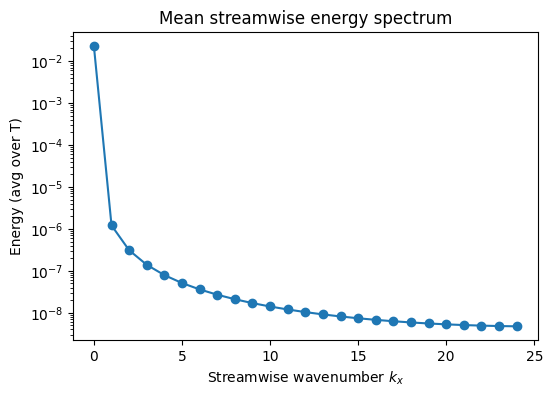

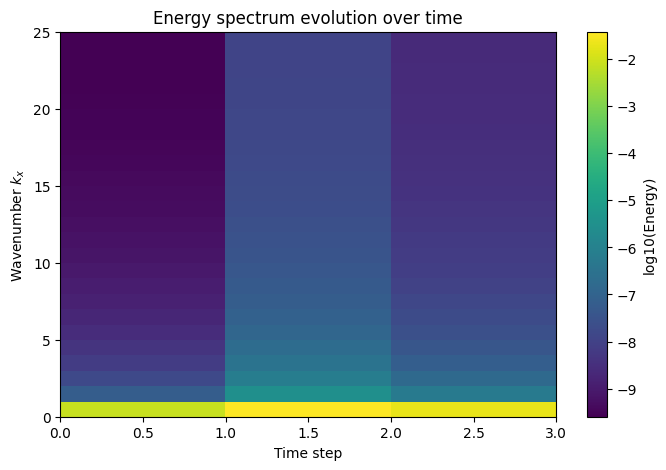

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# assume data.shape = (T, Nx, Ny, Nz) OR (T, Nx, Ny)
# adjust indexing if needed
T = data.shape[0]
Nx = data.shape[1]

# store energy spectra over time
energy_spectra = []

for t in range(T):
    # take snapshot at time t
    u_t = true_data[t]   # shape (Nx, Ny, Nz) or (Nx, Ny)

    # average over y,z (so we only keep x-dependence)
    u_x = np.mean(u_t, axis=tuple(range(1, u_t.ndim)))

    # 1D FFT along x
    u_hat = np.fft.fft(u_x, axis=0)

    # compute modal energy = |u_hat|^2
    E_k = np.abs(u_hat)**2 / Nx   # normalization optional

    # take only first half of spectrum (real data symmetry)
    E_k = E_k[:Nx//2]

    energy_spectra.append(E_k)

energy_spectra = np.array(energy_spectra)  # shape (T, Nx//2)

# --- Plot average spectrum ---
mean_spectrum = np.mean(energy_spectra, axis=0)
plt.figure(figsize=(6,4))
plt.semilogy(np.arange(len(mean_spectrum)), mean_spectrum, "o-")
plt.xlabel("Streamwise wavenumber $k_x$")
plt.ylabel("Energy (avg over T)")
plt.title("Mean streamwise energy spectrum")
plt.show()

# --- Plot spectrum evolution in time (heatmap) ---
plt.figure(figsize=(8,5))
plt.imshow(
    np.log10(energy_spectra.T + 1e-16),  # log for dynamic range
    origin="lower", aspect="auto",
    extent=[0, T, 0, Nx//2]
)
plt.colorbar(label="log10(Energy)")
plt.xlabel("Time step")
plt.ylabel("Wavenumber $k_x$")
plt.title("Energy spectrum evolution over time")
plt.show()


In [5]:
data[15].shape

(102, 129, 129, 1)

In [6]:
for i in range(len(data)): 
    if data[i].max() > 0.2: 
        print(i)
        print(data[i][0].min())

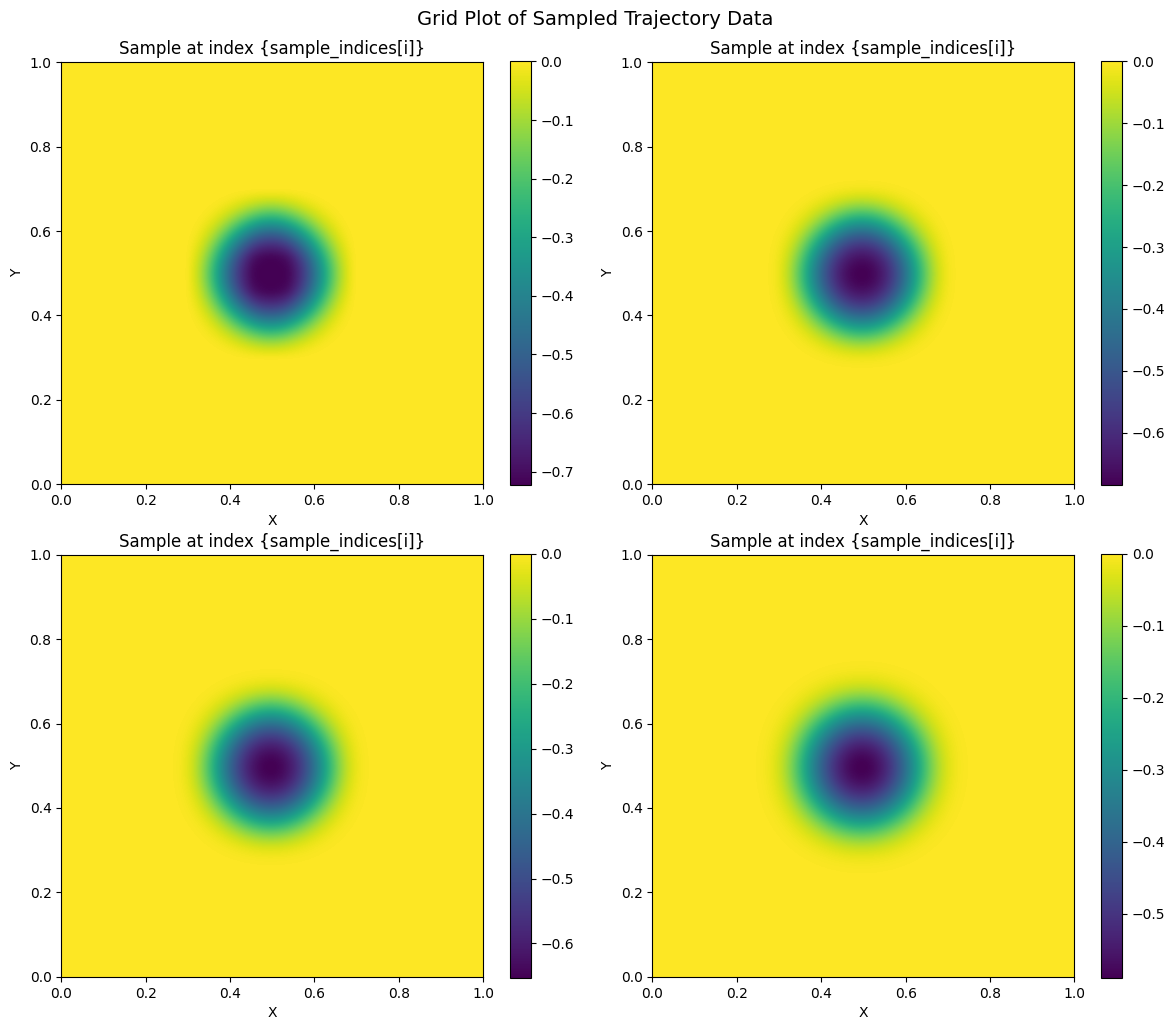

In [16]:
# plot samples from a single trajectory of data 
param64_data = true_data[2]
sample_indices = np.array([0, 15, 25, 48])
param64_data_samples = param64_data[sample_indices, :, :]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    # Extract the 2D field
    field = param64_data_samples[i, :, :, 0]

    # imshow instead of contourf
    im = axes[i].imshow(
        field,
        origin="lower",
        extent=[0, 1, 0, 1],  # match domain to [0,1]x[0,1]
        cmap="viridis",
        aspect="equal",
        interpolation="bilinear"
    )
    axes[i].set_title("Sample at index {sample_indices[i]}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    plt.colorbar(im, ax=axes[i])  # colorbar for each subplot

plt.tight_layout()
plt.suptitle("Grid Plot of Sampled Trajectory Data", y=1.02, fontsize=14)
plt.show()


MSE per snapshot: [6.92703346e-17 2.68386498e-06 1.18296375e-05 2.87253279e-05
 5.36011139e-05 8.60363725e-05 1.25276900e-04 1.70368687e-04
 2.20255184e-04 2.73863174e-04 3.30157141e-04 3.88165674e-04
 4.46990656e-04 5.05828182e-04 5.64005401e-04 6.21014566e-04
 6.76541298e-04 7.30464351e-04 7.82829942e-04 8.33806349e-04
 8.83622386e-04 9.32514202e-04 9.80668701e-04 1.02818722e-03
 1.07506267e-03 1.12117699e-03 1.16631808e-03 1.21022086e-03
 1.25262549e-03 1.29333907e-03 1.33229792e-03 1.36961171e-03
 1.40557624e-03 1.44065986e-03 1.47545384e-03 1.51059870e-03
 1.54669583e-03 1.58421532e-03 1.62342191e-03 1.66432641e-03
 1.70669786e-03 1.75013952e-03 1.79425930e-03 1.83890900e-03
 1.88445707e-03 1.93201960e-03 1.98351615e-03 2.04137829e-03
 2.10761302e-03 2.18186411e-03 2.25843978e-03]
Overall MSE: 0.0010633006


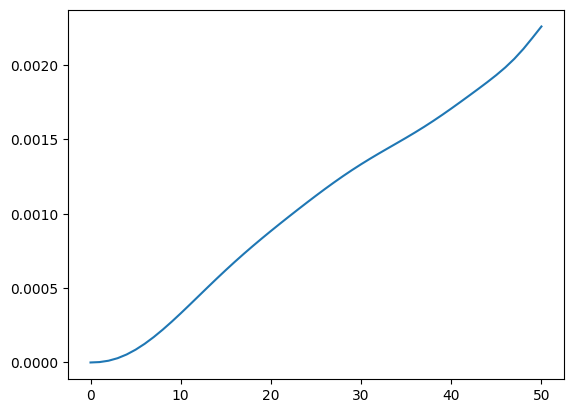

In [20]:
import numpy as np

# assume shapes: (nt, Ny, Nz) or (nt, Ny, Nz, 1)
pred = data[0]
truth = true_data[0]

# remove channel dimension if present
if pred.ndim == 4:
    pred = pred[..., 0]
if truth.ndim == 4:
    truth = truth[..., 0]

# compute MSE at each snapshot
mse_per_snapshot = np.mean((pred - truth) ** 2, axis=(1, 2))

# compute overall MSE
overall_mse = np.mean(mse_per_snapshot)

print("MSE per snapshot:", mse_per_snapshot)
print("Overall MSE:", overall_mse)

plt.plot(mse_per_snapshot)

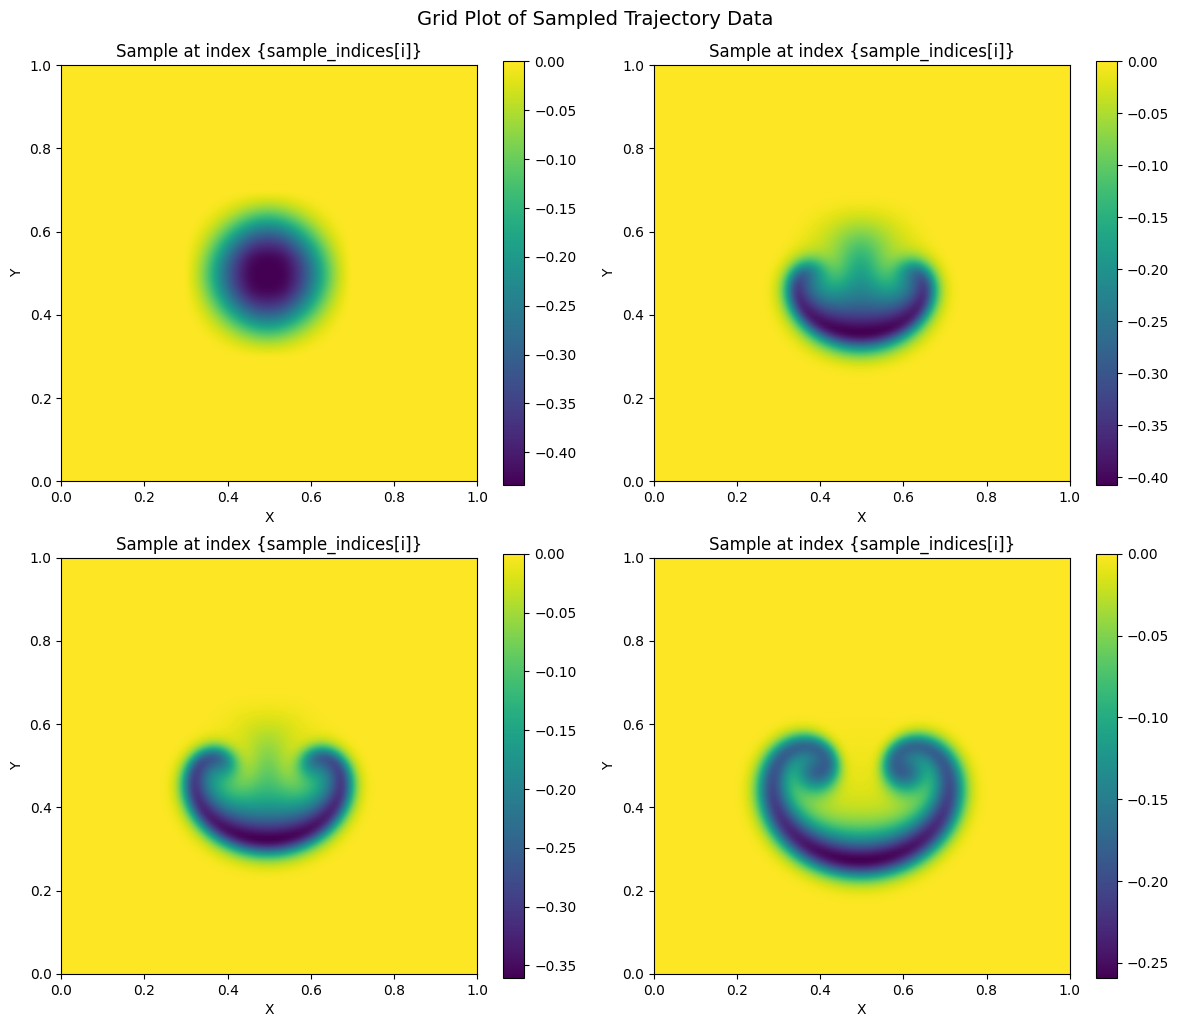

In [21]:
# plot samples from a single trajectory of data 
param64_data = true_data[2]
sample_indices = np.array([0, 15, 25, 50])
param64_data_samples = param64_data[sample_indices, :, :]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    # Extract the 2D field
    field = param64_data_samples[i, :, :, 0]

    # imshow instead of contourf
    im = axes[i].imshow(
        field,
        origin="lower",
        extent=[0, 1, 0, 1],  # match domain to [0,1]x[0,1]
        cmap="viridis",
        aspect="equal",
        interpolation="bilinear"
    )
    axes[i].set_title("Sample at index {sample_indices[i]}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    plt.colorbar(im, ax=axes[i])  # colorbar for each subplot

plt.tight_layout()
plt.suptitle("Grid Plot of Sampled Trajectory Data", y=1.02, fontsize=14)
plt.show()


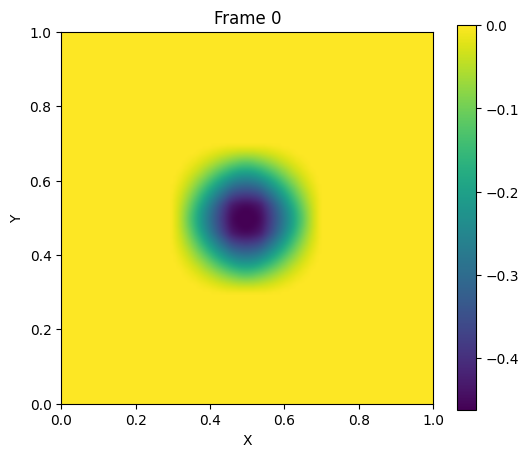

In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# pick a trajectory
param64_data = true_data[0]

# extract fields (T × 129 × 129 × 1)
fields = param64_data[..., 0]   # shape (T, 129, 129)

fig, ax = plt.subplots(figsize=(6, 5))

# initial frame
im = ax.imshow(
    fields[0],
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis",
    aspect="equal",
    interpolation="bilinear"
)

cbar = plt.colorbar(im, ax=ax)
ax.set_title("Trajectory Animation")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# update function
def update(frame):
    im.set_array(fields[frame])
    ax.set_title(f"Frame {frame}")
    return [im]

# create animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(fields),  # number of time steps
    interval=100,        # milliseconds per frame
    blit=True
)

plt.show()


In [3]:
# import trajectories with two different depth parameters
data_31 = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/re3:NSM:hdim16:depth10:modes12_31_31/uhat.npy")
data_11 = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/log/cw.X10/re3:NSM:hdim16:depth10:modes12_11_11/uhat.npy")

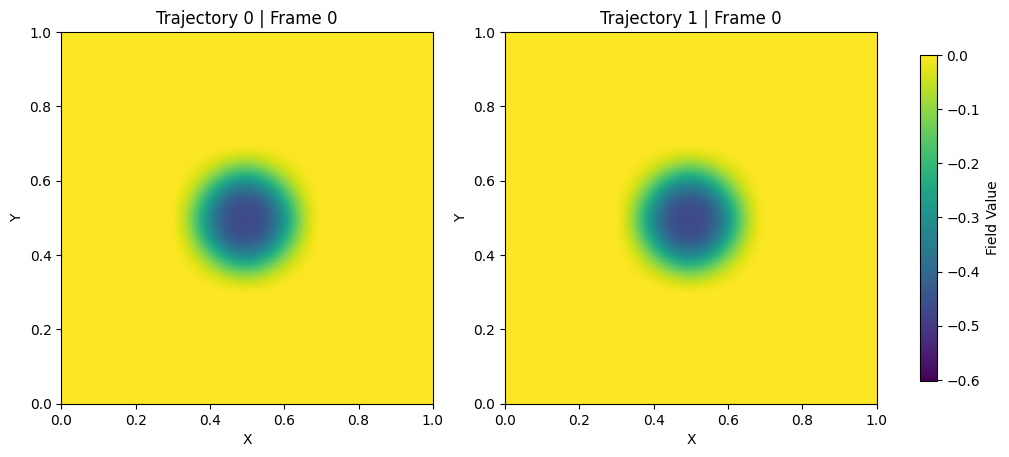

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# pick 2 random trajectories
indices = np.random.choice(len(true_data), 2, replace=False)
traj1, traj2 = true_data[0], data[0]

# extract fields (T × 129 × 129 × 1)
fields1 = traj1[..., 0]   # shape (T, 129, 129)
fields2 = traj2[..., 0]   # shape (T, 129, 129)

# ensure both have the same number of frames (truncate to min length)
T = min(len(fields1), len(fields2))
fields1, fields2 = fields1[:T], fields2[:T]

# compute global vmin/vmax for consistent scaling
vmin = min(fields1.min(), fields2.min())
vmax = 0.0

# figure and axes
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

im1 = axes[0].imshow(fields1[0], origin="lower", extent=[0, 1, 0, 1],
                     cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
axes[0].set_title(f"Trajectory {indices[0]} - 11 modes")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

im2 = axes[1].imshow(fields2[0], origin="lower", extent=[0, 1, 0, 1],
                     cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
axes[1].set_title(f"Trajectory {indices[1]} - 31 modes")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

# shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Field Value")

# update function
def update(frame):
    im1.set_array(fields1[frame])
    im2.set_array(fields2[frame])
    axes[0].set_title(f"Trajectory {indices[0]} | Frame {frame}")
    axes[1].set_title(f"Trajectory {indices[1]} | Frame {frame}")
    return [im1, im2]

# create animation
ani = animation.FuncAnimation(fig, update, frames=T, interval=100, blit=True)

plt.show()


In [18]:
ani.save("traj.gif", writer="pillow", fps=10)

In [65]:
data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/navierstokes/w.0.8x1.0.npy')

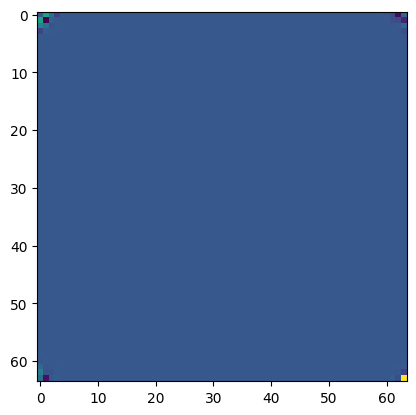

In [71]:
plt.imshow(data[0][0])

(64, 64, 1)
(64, 64, 1)
(64, 64, 1)
(64, 64, 1)
(64, 64, 1)


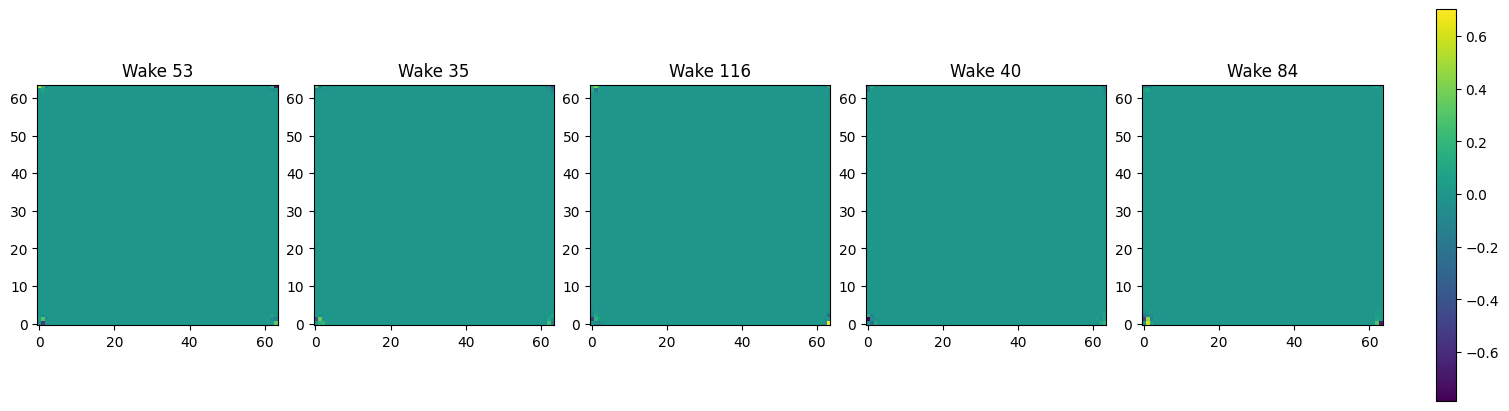

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# pick 5 random samples
n_samples = 5
indices = np.random.choice(len(data), n_samples, replace=False)

# compute global min and max for consistent color scaling
vmin = min(np.min(data[idx][0]) for idx in indices)
vmax = max(np.max(data[idx][0]) for idx in indices)

fig, axes = plt.subplots(1, n_samples, figsize=(15, 4), constrained_layout=True)

imgs = []
for ax, idx in zip(axes, indices):
    print(data[idx][1].shape)
    img = ax.imshow(data[idx][0], origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"Wake {idx}")
    imgs.append(img)

# add one shared colorbar
fig.colorbar(imgs[0], ax=axes, orientation="vertical", fraction=0.02, pad=0.04)

plt.show()


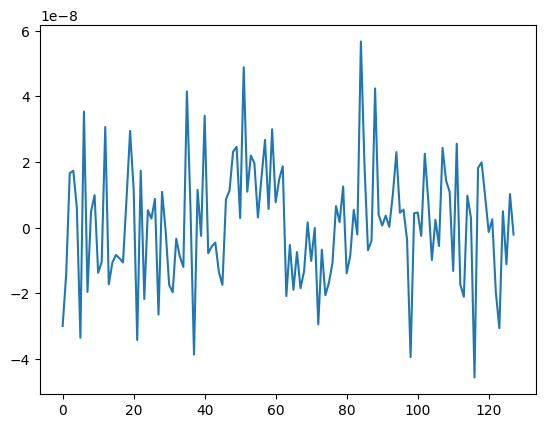

In [40]:
import matplotlib.pyplot as plt
plt.plot(data[:, 0, 0, 0, 0]) # spread of the variance parameters across samples used to generate the IC gaussian random fields

### Basis Function Transformation

In [22]:
data[0].shape

(64, 257, 257, 1)

In [23]:
def freq(n: int): return np.arange(n//2+1) * 2j * 3.14

def real(coef, n: int):

    """Complex coef -> Real coef"""

    cos, sin = coef.real, coef.imag[1:-(n//-2)]
    return np.concatenate((cos, sin[::-1]), 0)

a = np.moveaxis(real(np.moveaxis(np.exp(data[0] * -freq(2)), -1, 0), 2), 0, -1)

In [30]:
data[0][0]

array([[[0.61266184],
        [0.6387086 ],
        [0.6629261 ],
        ...,
        [0.5582541 ],
        [0.585505  ],
        [0.61266184]],

       [[0.60389817],
        [0.6285985 ],
        [0.65222573],
        ...,
        [0.5522118 ],
        [0.5782987 ],
        [0.60389817]],

       [[0.5929513 ],
        [0.6160774 ],
        [0.6388614 ],
        ...,
        [0.54435164],
        [0.56909895],
        [0.5929513 ]],

       ...,

       [[0.6223404 ],
        [0.6482767 ],
        [0.67183065],
        ...,
        [0.5678852 ],
        [0.59506667],
        [0.6223404 ]],

       [[0.61872697],
        [0.6452745 ],
        [0.6694958 ],
        ...,
        [0.5631847 ],
        [0.59089637],
        [0.61872697]],

       [[0.61266184],
        [0.6387086 ],
        [0.6629261 ],
        ...,
        [0.5582541 ],
        [0.585505  ],
        [0.61266184]]], dtype=float32)

In [28]:
a[0]

array([[[ 1.        , -0.76101264],
        [ 1.        , -0.64521069],
        [ 1.        , -0.52201631],
        ...,
        [ 1.        , -0.93439362],
        [ 1.        , -0.86007544],
        [ 1.        , -0.76101264]],

       [[ 1.        , -0.79554618],
        [ 1.        , -0.69238573],
        [ 1.        , -0.57811072],
        ...,
        [ 1.        , -0.9472356 ],
        [ 1.        , -0.88227491],
        [ 1.        , -0.79554618]],

       [[ 1.        , -0.83528714],
        [ 1.        , -0.74692332],
        [ 1.        , -0.64447714],
        ...,
        [ 1.        , -0.96189778],
        [ 1.        , -0.90798412],
        [ 1.        , -0.83528714]],

       ...,

       [[ 1.        , -0.72020058],
        [ 1.        , -0.59816665],
        [ 1.        , -0.47352839],
        ...,
        [ 1.        , -0.91115146],
        [ 1.        , -0.82790964],
        [ 1.        , -0.72020058]],

       [[ 1.        , -0.7357569 ],
        [ 1.        , -0.61